In [35]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain.tools import tool


In [36]:
class AgentState(TypedDict):
    messages: Annotated[list, "conversation between Human, AI and tools."]

In [37]:
@tool
def add(num1, num2):
    """
    Use this tool to add two numbers. 
    It takes num1 and num2 as inputs and returns the addition of those 2 numbers.
    """

    return num1 + num2

@tool
def subtract(num1, num2):
    """
    Use this tool to subtract two numbers. 
    It takes num1 and num2 as inputs and returns the subtraction of those 2 numbers.
    """

    return num1 - num2

In [38]:
tools = [add, subtract]
llm = ChatOpenAI(model='gpt-5-mini', temperature=0).bind_tools(tools=tools)

In [39]:
def agent(state):
    user_prompt = ChatPromptTemplate.from_messages(
        [
            ('system', 'You are a mathematical genius. Help me with my math problems'),
            ('user', '{user_message}')
        ]
    )

    agent_chain = user_prompt | llm
    agent_response = agent_chain.invoke(
        {
            'user_message': state['messages']
        }
    )

    state['messages'].append(agent_response)

    return state


In [40]:
tool_registry = {
    'add': add,
    'subtract': subtract
}

def tool_node(state):
    tool_calls = state['messages'][-1].tool_calls
    for tool_call in tool_calls:
        tool_name = tool_call['name']
        args = tool_call['args']
        tool_result = tool_registry[tool_name].invoke(args)
        state['messages'] += ToolMessage(content=tool_result, tool_call_id=tool_call['id'])
    return state

In [41]:
def tool_or_exit(state):
    last_message = state['messages'][-1]
    if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
        return 'Tool_Call'
    else:
        return 'End'

In [42]:
react_graph = StateGraph(AgentState)
react_graph.add_node('agent', agent)
react_graph.add_node('tool_node', tool_node)
react_graph.add_edge(START, 'agent')
react_graph.add_conditional_edges('agent', tool_or_exit, {'Tool_Call':'tool_node', 'End':END})
react_graph.add_edge('tool_node', 'agent')
react_graph.add_edge('agent', END)


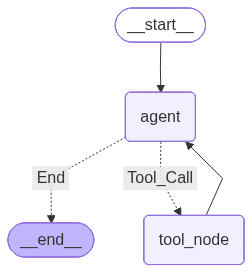

In [43]:
react_graph_compiled = react_graph.compile()
react_graph_compiled

In [44]:
# react_graph_compiled.invoke(
#     {
#         'messages': [
#             HumanMessage("What is 5 + 6 and What is 100-73")
#         ]
#     }
# )

for chunk in react_graph_compiled.stream(
    {
        'messages': [
            HumanMessage(content="What is 5 + 6 and What is 100-73")
        ]
    },
    stream_mode="updates"
):
    print(chunk)

{'agent': {'messages': [HumanMessage(content='What is 5 + 6 and What is 100-73', additional_kwargs={}, response_metadata={}), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 127, 'prompt_tokens': 240, 'total_tokens': 367, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-mini-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-DYF7IpA5dRgYAW3THY8I2ZcvJOmGt', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019dc0a6-8a9d-7861-aa50-5d246340be46-0', tool_calls=[{'name': 'add', 'args': {'num1': 5, 'num2': 6}, 'id': 'call_nVZYFl2BDlKzSNga3flgGlet', 'type': 'tool_call'}, {'name': 'subtract', 'args': {'num1': 100, 'num2': 73}, 'id': 'call_u0JvJwUulgl18gfudb3U3I6W', 'type': 'tool_c